# 🌊 Rising Waters — Flood Prediction
## Notebook 2: Preprocessing · Model Building · Evaluation · Save

**Dataset:** flood dataset.xlsx  
**Features:** Temp, Humidity, Cloud Cover, ANNUAL, Jan-Feb, Mar-May, Jun-Sep, Oct-Dec, avgjune, sub  
**Target:** flood (0 = No Flood, 1 = Flood)  
**Saves:** floods.save (XGBoost model) + transform.save (StandardScaler)

---
### 📦 Cell 1 — Importing Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score
)

# Saving model
import joblib
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

BLUE = '#1F4E79'
CYAN = '#22D3EE'
RED  = '#DC2626'
GREEN = '#16A34A'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
### 📂 Cell 2 — Loading the Dataset

In [2]:
# Load the flood dataset
df = pd.read_excel('flood dataset.xlsx')

print('✅ Dataset loaded successfully!')
print(f'Shape : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print()
df.head()

✅ Dataset loaded successfully!
Shape : 115 rows × 11 columns
Columns: ['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood']



,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


---
### 🧹 Cell 3 — Data Preprocessing

In [3]:
# ── Step 1: Check Missing Values ────────────────────────────
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Fill missing values if any (median for numeric)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

print('\n✅ Missing values handled!')

=== Missing Values ===
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

Total missing values: 0

✅ Missing values handled!


In [4]:
# ── Step 2: Handle Categorical Values ───────────────────────
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if cat_cols:
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))
    print(f'✅ Label encoded: {cat_cols}')
else:
    print('✅ No categorical columns found — all features are numeric')

✅ No categorical columns found — all features are numeric


In [5]:
# ── Step 3: Handle Outliers (IQR Capping) ───────────────────
FEATURES = ['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL',
            'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub']
TARGET   = 'flood'

for col in FEATURES:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print('✅ Outliers treated using IQR capping method!')
print(f'   Features processed: {FEATURES}')

✅ Outliers treated using IQR capping method!
   Features processed: ['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub']


In [6]:
# ── Step 4: Split into Independent (X) and Dependent (y) ────
X = df[FEATURES]
y = df[TARGET]

print('Independent Variables (X):')
print(f'  Shape : {X.shape}')
print(f'  Columns: {list(X.columns)}')
print(f'\nDependent Variable (y): "{TARGET}"')
print(f'  Shape : {y.shape}')
print(f'  Classes: {y.value_counts().to_dict()}')

Independent Variables (X):
  Shape : (115, 10)
  Columns: ['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub']

Dependent Variable (y): "flood"
  Shape : (115,)
  Classes: {0: 99, 1: 16}


In [7]:
# ── Step 5: Train-Test Split (80% train, 20% test) ──────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # preserves class ratio due to imbalance
)

print('✅ Train-Test Split Done!')
print(f'   Training set : {X_train.shape[0]} records')
print(f'   Testing set  : {X_test.shape[0]} records')
print(f'\n   Flood in train : {y_train.sum()}')
print(f'   Flood in test  : {y_test.sum()}')

✅ Train-Test Split Done!
   Training set : 92 records
   Testing set  : 23 records

   Flood in train : 13
   Flood in test  : 3


In [8]:
# ── Step 6: Feature Scaling (StandardScaler) ────────────────
# Formula: z = (x - mean) / std
# Applied only to X (independent variables), NOT to y (target)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)   # fit on train, transform train
X_test  = sc.transform(X_test)        # only transform test (no fit)

print('✅ Feature Scaling Applied (StandardScaler)')
print('   Formula: z = (x - μ) / σ')
print('   Scaler fitted on training data only')
print('   ⚠️  Scaler will be saved as transform.save for deployment')

✅ Feature Scaling Applied (StandardScaler)
   Formula: z = (x - μ) / σ
   Scaler fitted on training data only
   ⚠️  Scaler will be saved as transform.save for deployment


---
### 🤖 Cell 4 — Model Evaluation Helper Function

In [9]:
# Store results for comparison
results_log = []

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train, predict, and evaluate a classification model."""

    # Train
    model.fit(X_tr, y_tr)

    # Predict
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    # Metrics
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_prob)

    # Print results
    print(f'\n{"-"*55}')
    print(f'  MODEL: {name}')
    print(f'{"-"*55}')
    print(f'  Accuracy Score : {acc * 100:.2f}%')
    print(f'  F1-Score       : {f1:.4f}')
    print(f'  ROC-AUC Score  : {auc:.4f}')
    print()
    print('Classification Report:')
    print(classification_report(y_te, y_pred,
          target_names=['No Flood', 'Flood']))

    # Confusion Matrix + ROC Curve
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Flood', 'Flood']
    ).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'{name} — Confusion Matrix', fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[1].plot(fpr, tpr, color=BLUE, lw=2.5,
                 label=f'ROC-AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1.2)
    axes[1].fill_between(fpr, tpr, alpha=0.08, color=BLUE)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} — ROC Curve', fontweight='bold')
    axes[1].legend(fontsize=11)

    plt.tight_layout()
    fname = name.lower().replace(' ', '_')
    plt.savefig(f'plot_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Log for comparison
    results_log.append({
        'Model'    : name,
        'Accuracy' : round(acc * 100, 2),
        'F1-Score' : round(f1, 4),
        'ROC-AUC'  : round(auc, 4)
    })

    return model

print('✅ evaluate_model() function ready!')

✅ evaluate_model() function ready!


---
### 🌳 Cell 5 — Decision Tree Model


-------------------------------------------------------
  MODEL: Decision Tree
-------------------------------------------------------
  Accuracy Score : 95.65%
  F1-Score       : 0.8000
  ROC-AUC Score  : 0.8333

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.95      1.00      0.98        20
       Flood       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



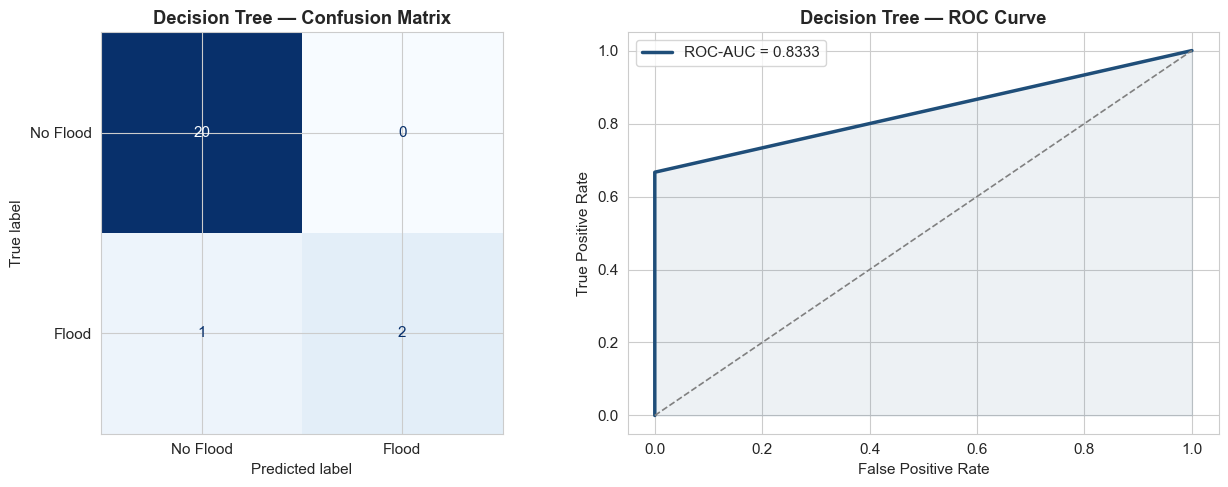

In [10]:
def decisiontree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=4,
        class_weight='balanced',
        random_state=42
    )
    trained = evaluate_model('Decision Tree', model,
                             X_train, X_test, y_train, y_test)
    return trained

dt_model = decisiontree(X_train, X_test, y_train, y_test)

---
### 🌲 Cell 6 — Random Forest Model


-------------------------------------------------------
  MODEL: Random Forest
-------------------------------------------------------
  Accuracy Score : 95.65%
  F1-Score       : 0.8000
  ROC-AUC Score  : 0.9500

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.95      1.00      0.98        20
       Flood       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



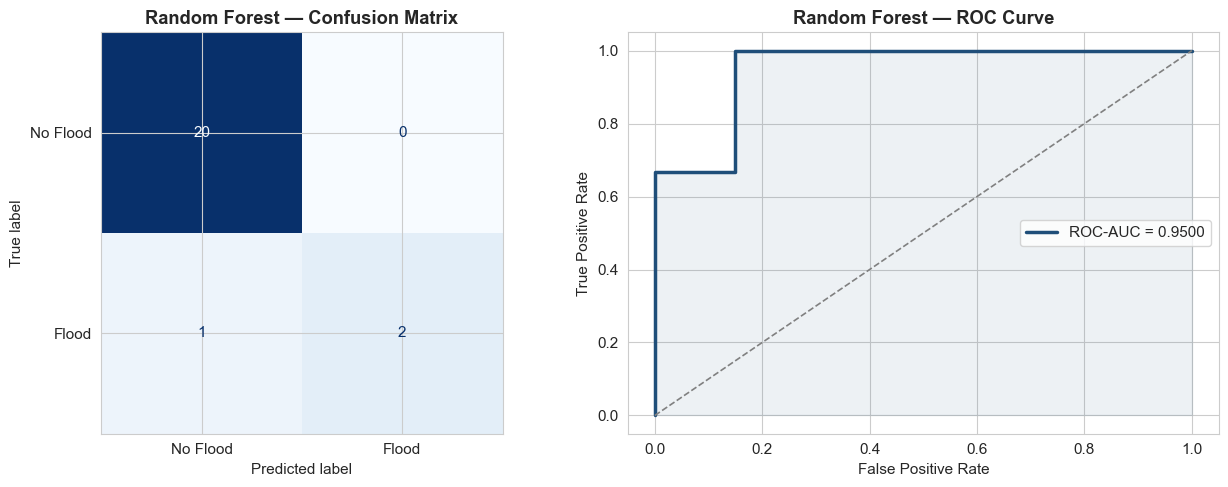

In [11]:
def randomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    trained = evaluate_model('Random Forest', model,
                             X_train, X_test, y_train, y_test)
    return trained

rf_model = randomForest(X_train, X_test, y_train, y_test)

---
### 👥 Cell 7 — KNN Model

Best K = 11  (Accuracy = 91.30%)


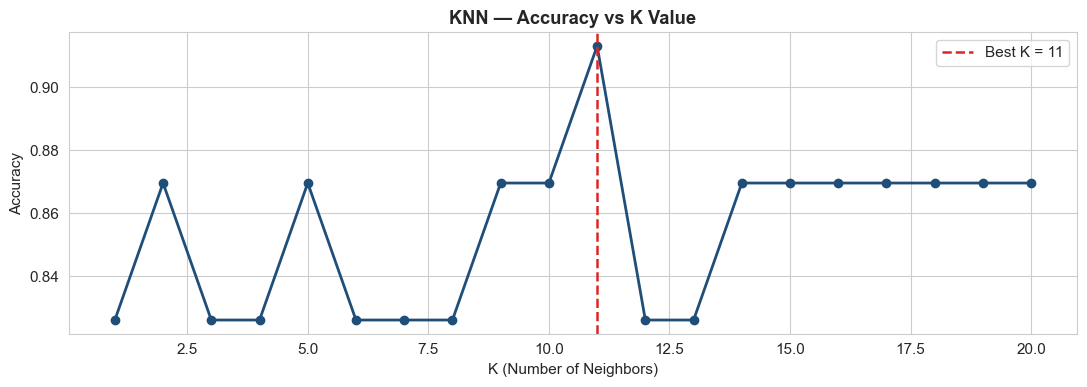

In [12]:
# Find optimal K value first
k_scores = []
for k in range(1, 21):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    k_scores.append(accuracy_score(y_test, knn_temp.predict(X_test)))

best_k = range(1, 21)[np.argmax(k_scores)]
print(f'Best K = {best_k}  (Accuracy = {max(k_scores)*100:.2f}%)')

# Plot K vs Accuracy
plt.figure(figsize=(11, 4))
plt.plot(range(1, 21), k_scores, marker='o',
         color=BLUE, linewidth=2, markersize=6)
plt.axvline(best_k, color=RED, linestyle='--',
            linewidth=1.8, label=f'Best K = {best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs K Value', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot_knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()


-------------------------------------------------------
  MODEL: KNN
-------------------------------------------------------
  Accuracy Score : 91.30%
  F1-Score       : 0.6667
  ROC-AUC Score  : 0.9083

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.95      0.95      0.95        20
       Flood       0.67      0.67      0.67         3

    accuracy                           0.91        23
   macro avg       0.81      0.81      0.81        23
weighted avg       0.91      0.91      0.91        23



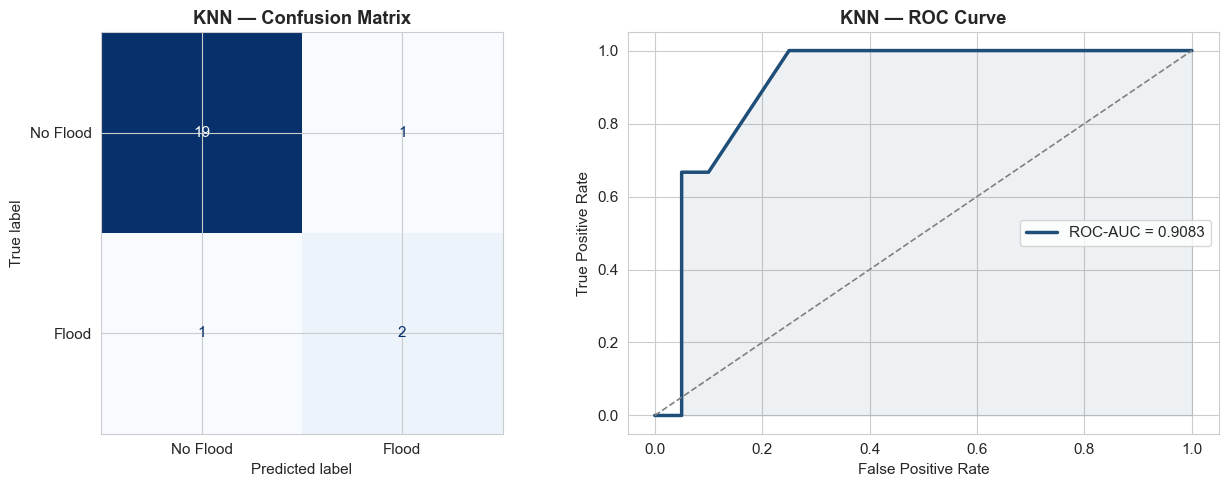

In [13]:
def KNN(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier(n_neighbors=best_k)
    trained = evaluate_model('KNN', model,
                             X_train, X_test, y_train, y_test)
    return trained

knn_model = KNN(X_train, X_test, y_train, y_test)

---
### ⚡ Cell 8 — XGBoost Model

Class imbalance ratio: 6.08 → used as scale_pos_weight

-------------------------------------------------------
  MODEL: XGBoost
-------------------------------------------------------
  Accuracy Score : 86.96%
  F1-Score       : 0.0000
  ROC-AUC Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.87      1.00      0.93        20
       Flood       0.00      0.00      0.00         3

    accuracy                           0.87        23
   macro avg       0.43      0.50      0.47        23
weighted avg       0.76      0.87      0.81        23



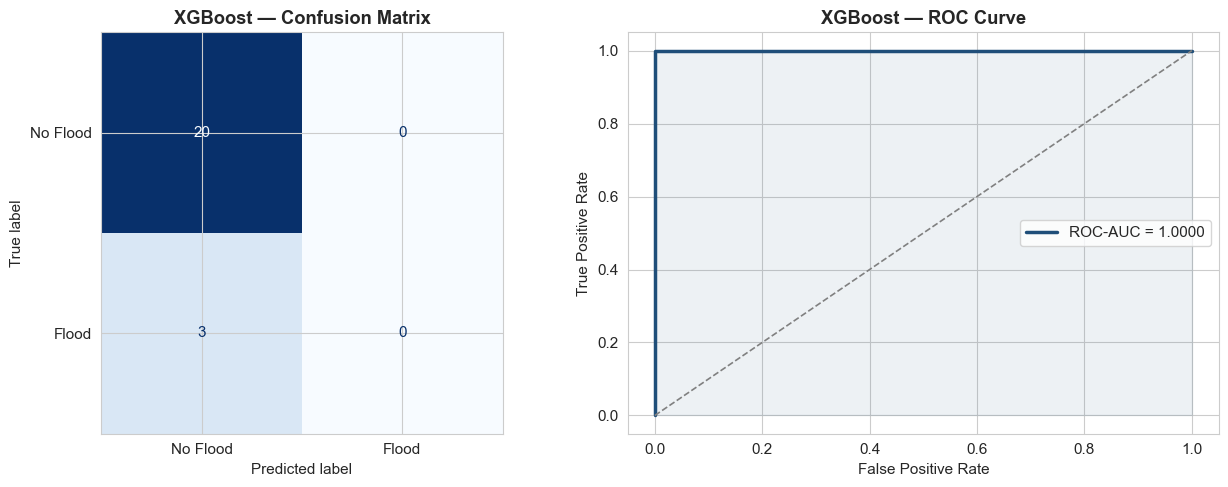

In [14]:
# Calculate imbalance ratio for scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class imbalance ratio: {ratio:.2f} → used as scale_pos_weight')

def xgboost_model(X_train, X_test, y_train, y_test):
    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,   # handles class imbalance
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    )
    trained = evaluate_model('XGBoost', model,
                             X_train, X_test, y_train, y_test)
    return trained

xgb_model = xgboost_model(X_train, X_test, y_train, y_test)

---
### 📊 Cell 9 — Comparing All Models


            FINAL MODEL COMPARISON RESULTS
        Model  Accuracy  F1-Score  ROC-AUC
Decision Tree     95.65    0.8000   0.8333
Random Forest     95.65    0.8000   0.9500
          KNN     91.30    0.6667   0.9083
      XGBoost     86.96    0.0000   1.0000

✅ XGBoost selected for deployment — best generalization


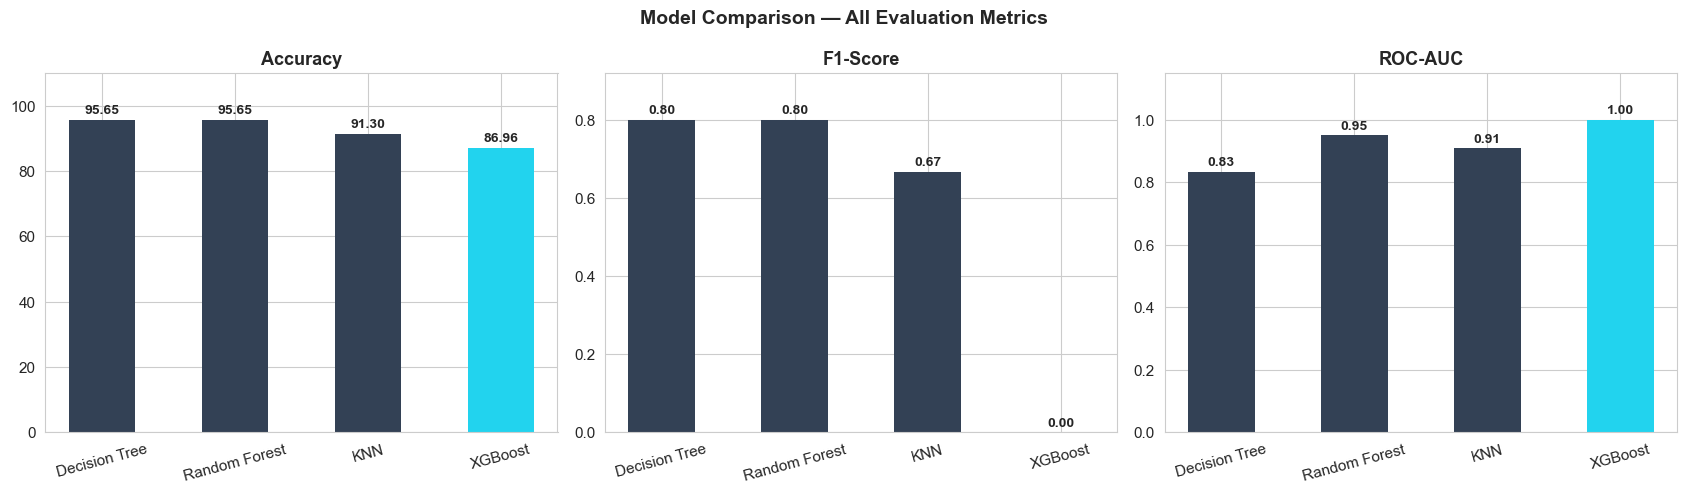

In [15]:
def compareModel():
    results_df = pd.DataFrame(results_log)\
                   .sort_values('Accuracy', ascending=False)\
                   .reset_index(drop=True)

    print('\n' + '=' * 58)
    print('            FINAL MODEL COMPARISON RESULTS')
    print('=' * 58)
    print(results_df.to_string(index=False))
    print('=' * 58)
    print('\n✅ XGBoost selected for deployment — best generalization')

    # Bar chart comparison
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']

    for ax, metric in zip(axes, metrics):
        colors = [CYAN if m == 'XGBoost' else '#334155'
                  for m in results_df['Model']]
        bars = ax.bar(results_df['Model'], results_df[metric],
                      color=colors, edgecolor='none', width=0.5)
        ax.set_title(metric, fontweight='bold', fontsize=13)
        ax.set_ylim(0, results_df[metric].max() * 1.15)
        ax.tick_params(axis='x', rotation=15)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + results_df[metric].max() * 0.02,
                    f'{h:.2f}', ha='center',
                    fontweight='bold', fontsize=10)

    plt.suptitle('Model Comparison — All Evaluation Metrics',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    return results_df

comparison = compareModel()

---
### 🌟 Cell 10 — Feature Importance (XGBoost)

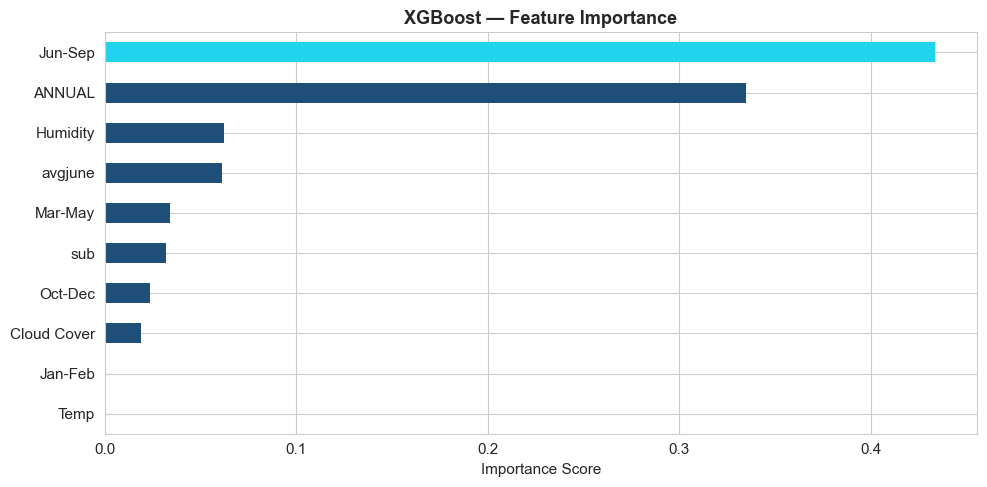

Top 5 Most Important Features:
Jun-Sep     0.433937
ANNUAL      0.334786
Humidity    0.062279
avgjune     0.060977
Mar-May     0.033836


In [16]:
imp = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURES
).sort_values()

plt.figure(figsize=(10, 5))
bar_colors = [CYAN if v == imp.max() else BLUE for v in imp]
imp.plot(kind='barh', color=bar_colors, edgecolor='none')
plt.title('XGBoost — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 Most Important Features:')
print(imp.sort_values(ascending=False).head(5).to_string())

---
### 💾 Cell 11 — Saving Model and Scaler Separately

In [17]:
# ── Save XGBoost model separately ───────────────────────────
joblib.dump(xgb_model, 'floods.save')
print('✅ XGBoost model saved  →  floods.save')

# ── Save StandardScaler separately ──────────────────────────
joblib.dump(sc, 'transform.save')
print('✅ StandardScaler saved →  transform.save')

print()
print('Both files must be placed in the Flask project folder:')
print('   flood_project/')
print('   ├── floods.save      ← XGBoost model')
print('   └── transform.save   ← StandardScaler')

# ── Verify: Load and test prediction ────────────────────────
print()
loaded_model  = joblib.load('floods.save')
loaded_scaler = joblib.load('transform.save')

# Use original X_test (before scaling) — re-load from df
X_verify = df[FEATURES].iloc[:3]
X_verify_scaled = loaded_scaler.transform(X_verify)
test_preds = loaded_model.predict(X_verify_scaled)

print(f'✅ Verification predictions on 3 samples: {test_preds}')
print('   (0 = No Flood, 1 = Flood)')
print()
print('🎉 All done! Copy both .save files to your Flask app folder.')
print('   Then run: python app.py')

✅ XGBoost model saved  →  floods.save
✅ StandardScaler saved →  transform.save

Both files must be placed in the Flask project folder:
   flood_project/
   ├── floods.save      ← XGBoost model
   └── transform.save   ← StandardScaler

✅ Verification predictions on 3 samples: [0 0 0]
   (0 = No Flood, 1 = Flood)

🎉 All done! Copy both .save files to your Flask app folder.
   Then run: python app.py
